# Buckley Steerer — Degauss FFMM Golden Parity

Validate this Python analyzer against the **FFMM C++ legacy analyzer** golden
results on the *StandardDegauss* run of the Carbonara Buckley-steerer test, and
provide a first look at the degaussing field decay.

The dataset is a degaussing staircase on a combined H/V steerer (declared a
**dipole**, $m = 1$): an alternating-polarity, decaying-amplitude current
sequence applied first on the horizontal channel (runs $0\ldots36$) and then on
the vertical channel (runs $37\ldots73$). Each run is a measurement plateau at a
fixed current with the rotating coil; the legacy analyzer wrote a per-turn
`*_Main_results.txt` (the golden reference) next to the raw
`*_Main_raw_measurement_data.txt`.

This notebook is a **deterministic validation pipeline**: it produces the parity
verdict, figures, and CSVs on disk. It does not hard-code numerical conclusions
in prose — the code computes the truth.

## Configuration

Settings are taken verbatim from the run's `Parameters.txt`, which records the
exact analyzer options the FFMM golden export used:

- `magnetAnalyzer.dri = true`, `rot = true`, everything else (`abs`, `cel`,
  `fed`, `nor`) `false` $\Rightarrow$ `OPTIONS = ("dri", "rot")` and output in
  **Tesla** (no normalisation to units).
- `refRadius = 0.04` m, `magnetType = Dipole` $\Rightarrow m = 1$.
- `samples = 1024` per turn, `turns = 10`. The raw file actually contains 20
  physical turns (~2 rev/s); the golden `results.txt` has exactly 10 rows, so
  FFMM analysed the **first 10 turns of 1024 samples**. We mirror that by
  reshaping the first `n_golden_rows * 1024` samples.
- Merge policy: main harmonic from the **absolute** channel, higher orders from
  the **compensated** channel (`abs_upto_m_cmp_above`), matching FFMM for a
  compensated dipole measurement.
- `legacy_rotate_excludes_last = True`: FFMM's rotation loop skips the last
  harmonic ($n = H$). This is a known C++ off-by-one; we reproduce it for exact
  parity and revisit it later.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import process_kn_pipeline

In [2]:
def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    return start.resolve()

REPO = _find_repo_root(Path.cwd())
DATA = (REPO / "golden_standards" / "degaussing_test" / "StandardDegauss"
        / "20260623_165352_Carbonara_test_Buckley-steerer")

# The single sub-directory that actually holds the per-run files.
RUNDIR = next(d for d in sorted(DATA.iterdir())
              if d.is_dir() and any(d.glob("*_Main_raw_measurement_data.txt")))
KN_PATH = DATA / "Kn_values_Seg_Main.txt"

# FFMM golden analyzer settings (from Parameters.txt)
R_REF = 0.04
MAGNET_ORDER = 1
SAMPLES_PER_TURN = 1024
OPTIONS = ("dri", "rot")
MERGE_MODE = "abs_upto_m_cmp_above"
LEGACY_ROTATE_EXCLUDES_LAST = True   # FFMM excludes the last harmonic from rotation
PARITY_FLOOR_T = 1e-12               # float64 parity floor for these magnitudes

figures_path = Path("figures")
figures_path.mkdir(parents=True, exist_ok=True)
csv_path = Path("csv")
csv_path.mkdir(parents=True, exist_ok=True)

kn = load_segment_kn_txt(str(KN_PATH))
H = int(kn.orders.size)
print("REPO     :", REPO)
print("RUNDIR   :", RUNDIR.name)
print("Kn orders:", H)

REPO     : C:\Users\albellel\python-projects\rotating-coil-analyzer
RUNDIR   : 20260623_165410_Buckley-steerer
Kn orders: 15


## Discover the degauss runs

Parse every `..._Run_<id>IH_<Ih>IV_<Iv>_Main_raw_measurement_data.txt` filename
into a run id and the set H/V currents. The vertical sweep starts at the first
run with a non-zero $I_V$; runs before it are the horizontal degauss, runs from
it onward are the vertical degauss. `I_set` is the active channel's set current.

In [3]:
PAT = re.compile(r"_Run_(\d+)IH_([-0-9.]+)IV_([-0-9.]+)_Main_raw_measurement_data\.txt$")

runs = []
for f in sorted(RUNDIR.glob("*_Main_raw_measurement_data.txt")):
    m = PAT.search(f.name)
    if not m:
        continue
    runs.append(dict(
        run_id=int(m.group(1)),
        IH=float(m.group(2)),
        IV=float(m.group(3)),
        stem=f.name[: -len("_raw_measurement_data.txt")],
    ))
runs.sort(key=lambda r: r["run_id"])

v_start = min((r["run_id"] for r in runs if r["IV"] != 0.0), default=10**9)
for r in runs:
    r["channel"] = "H" if r["run_id"] < v_start else "V"
    r["I_set"] = r["IH"] if r["channel"] == "H" else r["IV"]

print(f"{len(runs)} runs | vertical degauss starts at run {v_start}")
pd.DataFrame(runs)[["run_id", "channel", "IH", "IV", "I_set"]].head()

74 runs | vertical degauss starts at run 37


,run_id,channel,IH,IV,I_set
0,0,H,10.000,0.0,10.000
1,1,H,-10.000,0.0,-10.000
2,2,H,6.667,0.0,6.667
3,3,H,-6.667,0.0,-6.667
4,4,H,4.444,0.0,4.444


## Loader and pipeline wrapper

`load_run` reads the raw 4-column file (`t, df_abs, df_cmp, I`) and the golden
`results.txt`. `analyze_run` reshapes the first `n_turns x 1024` samples into
turns and runs the full Kn pipeline with the FFMM-matching settings, returning
the per-turn merged complex harmonics (Tesla) to compare against the golden.

In [4]:
def load_run(stem):
    raw = np.loadtxt(RUNDIR / f"{stem}_raw_measurement_data.txt")
    gold = pd.read_csv(RUNDIR / f"{stem}_results.txt", sep="\t")
    return raw, gold


def analyze_run(raw, n_turns, excludes_last=LEGACY_ROTATE_EXCLUDES_LAST):
    n_use = n_turns * SAMPLES_PER_TURN
    t = raw[:n_use, 0].reshape(n_turns, SAMPLES_PER_TURN)
    da = raw[:n_use, 1].reshape(n_turns, SAMPLES_PER_TURN)
    dc = raw[:n_use, 2].reshape(n_turns, SAMPLES_PER_TURN)
    I = raw[:n_use, 3].reshape(n_turns, SAMPLES_PER_TURN)
    result, C_merged, C_units, ok_main = process_kn_pipeline(
        da, dc, t, I, kn=kn, r_ref=R_REF, magnet_order=MAGNET_ORDER,
        options=OPTIONS, merge_mode=MERGE_MODE,
        legacy_rotate_excludes_last=excludes_last,
    )
    return result, C_merged

## Parity loop

For every run, compute our per-turn $B_n / A_n$ (Tesla) and compare against the
golden `B{n}(T)` / `A{n}(T)` columns. We track the maximum absolute difference
per order (across turns) globally and per run, and store the per-run mean main
field for the physics view. Results are written to `csv/`.

In [5]:
per_run = []
per_order_absmax = np.zeros(H)
worst_overall = 0.0
worst_where = (None, None)

for r in runs:
    raw, gold = load_run(r["stem"])
    n_turns = len(gold)
    result, C_merged = analyze_run(raw, n_turns)

    run_worst, run_worst_n = 0.0, 0
    for n in range(1, H + 1):
        dB = np.abs(np.real(C_merged[:, n - 1]) - gold[f"B{n}(T)"].to_numpy())
        dA = np.abs(np.imag(C_merged[:, n - 1]) - gold[f"A{n}(T)"].to_numpy())
        d = float(max(dB.max(), dA.max()))
        per_order_absmax[n - 1] = max(per_order_absmax[n - 1], d)
        if d > run_worst:
            run_worst, run_worst_n = d, n
    if run_worst > worst_overall:
        worst_overall, worst_where = run_worst, (r["run_id"], run_worst_n)

    per_run.append(dict(
        run_id=r["run_id"], channel=r["channel"], I_set=r["I_set"],
        I_meas_A=float(result.I_mean_A.mean()),
        B1_mean_T=float(np.real(C_merged[:, MAGNET_ORDER - 1]).mean()),
        B1_std_T=float(np.real(C_merged[:, MAGNET_ORDER - 1]).std()),
        golden_B1_mean_T=float(gold["B1(T)"].mean()),
        worst_absdiff_T=run_worst, worst_order=run_worst_n, n_turns=n_turns,
    ))

parity_df = pd.DataFrame(per_run)
order_df = pd.DataFrame({"order": np.arange(1, H + 1),
                         "global_max_absdiff_T": per_order_absmax})
parity_df.to_csv(csv_path / "parity_summary.csv", index=False)
order_df.to_csv(csv_path / "parity_per_order.csv", index=False)

print(f"runs analysed     : {len(parity_df)}")
print(f"worst |delta|     : {worst_overall:.3e} T")
print(f"worst location    : run {worst_where[0]}, order n={worst_where[1]}")
parity_df.head()

runs analysed     : 74
worst |delta|     : 9.986e-17 T
worst location    : run 2, order n=1


,run_id,channel,I_set,I_meas_A,B1_mean_T,B1_std_T,golden_B1_mean_T,worst_absdiff_T,worst_order,n_turns
0,0,H,10.000,1001.151766,-0.000971,3.472151e-08,-0.000971,8.944668e-17,1,10
1,1,H,-10.000,1000.704802,0.000839,2.323416e-08,0.000839,8.532671e-17,1,10
2,2,H,6.667,1000.340561,-0.000665,3.776551e-08,-0.000665,9.985502e-17,1,10
3,3,H,-6.667,999.964798,0.000542,1.819569e-08,0.000542,8.803722e-17,1,10
4,4,H,4.444,999.471749,-0.000463,2.053307e-08,-0.000463,9.595189e-17,1,10


## Parity verdict

A single absolute tolerance is meaningful here because the golden output is in
Tesla and the coefficients span ~$10^{-3}$ (main) down to ~$10^{-8}$ (high
orders). The float64 rounding floor for these magnitudes is ~$10^{-12}$ T. The
assertion makes the notebook fail loudly if parity ever regresses.

In [6]:
verdict = "MACHINE-PRECISION PARITY" if worst_overall < PARITY_FLOOR_T else "DIVERGENCE"
print(f"Worst absolute difference over {len(parity_df)} runs x {H} orders x turns:")
print(f"    {worst_overall:.3e} T   ->   {verdict}   (floor = {PARITY_FLOOR_T:.0e} T)")
assert worst_overall < PARITY_FLOOR_T, "Parity broken vs FFMM golden -- investigate."
order_df

Worst absolute difference over 74 runs x 15 orders x turns:
    9.986e-17 T   ->   MACHINE-PRECISION PARITY   (floor = 1e-12 T)


,order,global_max_absdiff_T
0,1,9.985502e-17
1,2,2.117596e-18
2,3,1.163823e-18
3,4,7.597356e-19
4,5,7.014227e-19
5,6,5.851012e-19
6,7,5.606382e-19
7,8,4.644123e-19
8,9,6.253783e-19
9,10,6.732721e-19


## Parity figure

Left: our per-run mean $B_1$ against the golden $B_1$ (the $y = x$ line is exact
agreement). Right: the global maximum $|\Delta|$ per harmonic order on a log
scale, with the parity floor marked.

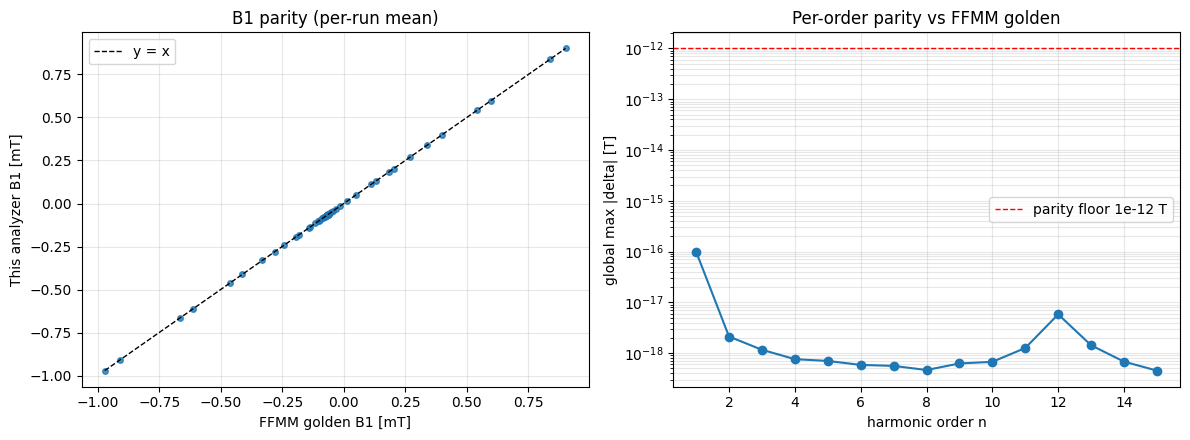

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(parity_df["golden_B1_mean_T"] * 1e3, parity_df["B1_mean_T"] * 1e3,
           "o", ms=4, alpha=0.8)
lim = [parity_df[["golden_B1_mean_T", "B1_mean_T"]].min().min() * 1e3,
       parity_df[["golden_B1_mean_T", "B1_mean_T"]].max().max() * 1e3]
ax[0].plot(lim, lim, "k--", lw=1, label="y = x")
ax[0].set_xlabel("FFMM golden B1 [mT]")
ax[0].set_ylabel("This analyzer B1 [mT]")
ax[0].set_title("B1 parity (per-run mean)")
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].semilogy(order_df["order"],
               np.maximum(order_df["global_max_absdiff_T"], 1e-20), "o-")
ax[1].axhline(PARITY_FLOOR_T, color="r", ls="--", lw=1,
              label=f"parity floor {PARITY_FLOOR_T:.0e} T")
ax[1].set_xlabel("harmonic order n")
ax[1].set_ylabel("global max |delta| [T]")
ax[1].set_title("Per-order parity vs FFMM golden")
ax[1].legend(); ax[1].grid(alpha=0.3, which="both")

plt.tight_layout()
for ext in ("svg", "png"):
    fig.savefig(figures_path / f"parity_overview.{ext}")
plt.show()

## Which is "better": the last-harmonic rotation off-by-one

Parity is exact for orders $n = 1 \ldots H-1$. The only place the two analyzers
can disagree is the **last harmonic** $n = H$: FFMM's rotation loop skips it (a
C++ off-by-one), whereas Bottura Eq. AIV.6 rotates **all** harmonics
$k = 1 \ldots H$. We re-run one representative run both ways and compare each to
the golden. `exclude-last` should match the golden to the floor; `rotate-all`
should match for $n < H$ and differ at $n = H$ by exactly the FFMM artifact.

There is no measurement reason to leave $n = H$ unrotated (it sits far below
Nyquist), so `rotate-all` is the physically correct convention — our analyzer
defaults to it and only switches it off to reproduce the legacy export.

In [8]:
rep = runs[0]
raw, gold = load_run(rep["stem"])
n_turns = len(gold)
_, Cm_excl = analyze_run(raw, n_turns, excludes_last=True)
_, Cm_all = analyze_run(raw, n_turns, excludes_last=False)

rows = []
for n in range(1, H + 1):
    gB = gold[f"B{n}(T)"].to_numpy()
    gA = gold[f"A{n}(T)"].to_numpy()
    d_excl = max(np.abs(np.real(Cm_excl[:, n - 1]) - gB).max(),
                 np.abs(np.imag(Cm_excl[:, n - 1]) - gA).max())
    d_all = max(np.abs(np.real(Cm_all[:, n - 1]) - gB).max(),
                np.abs(np.imag(Cm_all[:, n - 1]) - gA).max())
    rows.append(dict(order=n, dabs_exclude_last_T=d_excl, dabs_rotate_all_T=d_all))

rot_df = pd.DataFrame(rows)
rot_df.to_csv(csv_path / "rotation_offbyone_run0.csv", index=False)
print(f"Per-order |delta| vs FFMM golden, run {rep['run_id']} ({rep['channel']}-channel):")
rot_df

Per-order |delta| vs FFMM golden, run 0 (H-channel):


,order,dabs_exclude_last_T,dabs_rotate_all_T
0,1,8.944668e-17,8.944668e-17
1,2,2.371692e-20,2.371692e-20
2,3,1.578658e-19,1.578658e-19
3,4,8.867376e-21,8.867376e-21
4,5,1.736418e-20,1.736418e-20
5,6,3.229313e-21,3.229313e-21
6,7,1.549144e-20,1.549144e-20
7,8,2.771717e-20,2.771717e-20
8,9,1.576275e-20,1.576275e-20
9,10,3.065200e-20,3.065200e-20


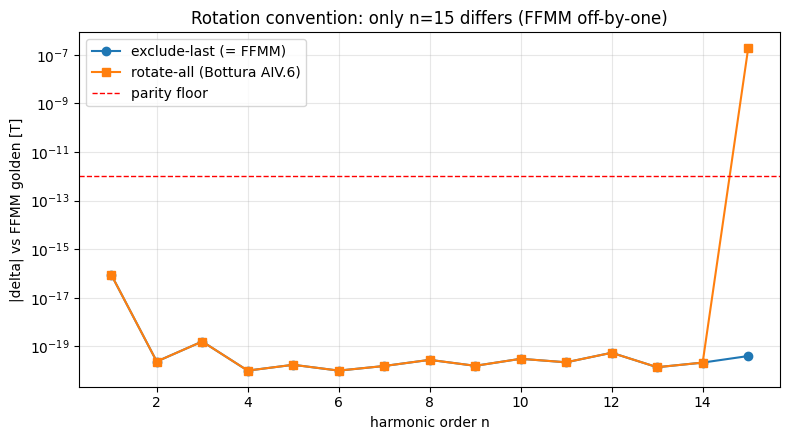

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(rot_df["order"], np.maximum(rot_df["dabs_exclude_last_T"], 1e-20),
            "o-", label="exclude-last (= FFMM)")
ax.semilogy(rot_df["order"], np.maximum(rot_df["dabs_rotate_all_T"], 1e-20),
            "s-", label="rotate-all (Bottura AIV.6)")
ax.axhline(PARITY_FLOOR_T, color="r", ls="--", lw=1, label="parity floor")
ax.set_xlabel("harmonic order n")
ax.set_ylabel("|delta| vs FFMM golden [T]")
ax.set_title(f"Rotation convention: only n={H} differs (FFMM off-by-one)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout()
for ext in ("svg", "png"):
    fig.savefig(figures_path / f"rotation_offbyone.{ext}")
plt.show()

## Degaussing field overview

With parity established, look at the physics the run captures. The **commanded
set current** `I_set` (from the filename) is the degauss drive — it alternates
sign with decaying amplitude. Note the raw current column in the data files is a
near-constant reference (~$10^3$, no sign flip), so it is *not* the excitation
axis; we use the signed `I_set`. (This does not affect the parity above, which
compares harmonics and uses the same recorded column as FFMM.)

For each channel we plot the main field $B_1$ (mean over the 10 turns, error
bars = std) against the degauss step index and against `I_set`. A successful
degauss collapses the alternating excursions toward the origin.

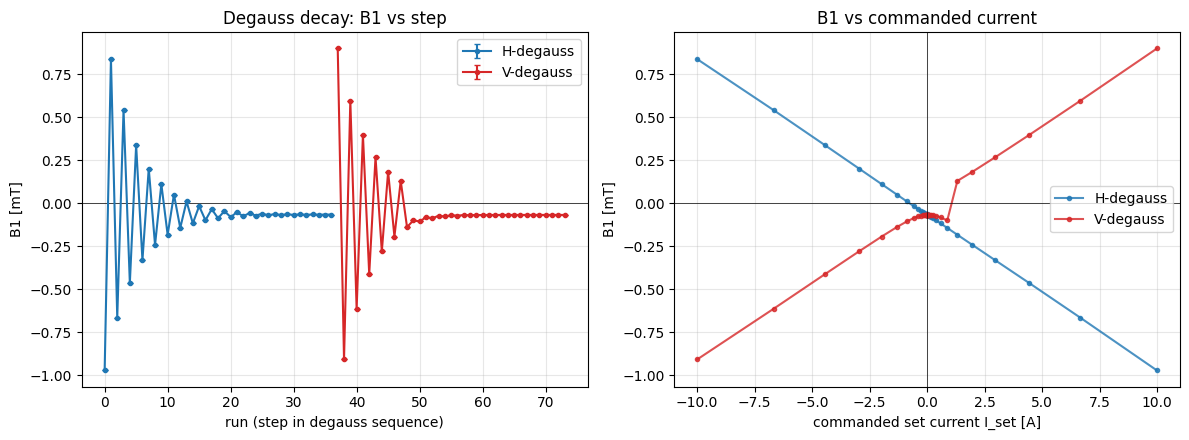

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for ch, color in [("H", "tab:blue"), ("V", "tab:red")]:
    sub = parity_df[parity_df["channel"] == ch].sort_values("run_id")
    ax[0].errorbar(sub["run_id"], sub["B1_mean_T"] * 1e3, yerr=sub["B1_std_T"] * 1e3,
                   fmt="o-", ms=3, capsize=2, color=color, label=f"{ch}-degauss")
    s2 = sub.sort_values("I_set")
    ax[1].plot(s2["I_set"], s2["B1_mean_T"] * 1e3, "o-", ms=3,
               color=color, alpha=0.8, label=f"{ch}-degauss")
ax[0].set_xlabel("run (step in degauss sequence)")
ax[0].set_ylabel("B1 [mT]")
ax[0].set_title("Degauss decay: B1 vs step")
ax[0].axhline(0, color="k", lw=0.5)
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_xlabel("commanded set current I_set [A]")
ax[1].set_ylabel("B1 [mT]")
ax[1].set_title("B1 vs commanded current")
ax[1].axhline(0, color="k", lw=0.5); ax[1].axvline(0, color="k", lw=0.5)
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
for ext in ("svg", "png"):
    fig.savefig(figures_path / f"degauss_field.{ext}")
plt.show()

## Residual field after degauss

The degauss result is the remanent main field at the final zero-set-current
step of each channel ($I_\text{set} = 0$). We pick, per channel, the run with
the smallest $|I_\text{set}|$ and report its mean $B_1$ and spread. Saved to
`csv/degauss_residual.csv`.

In [11]:
res_rows = []
for ch in ("H", "V"):
    sub = parity_df[parity_df["channel"] == ch]
    zero = sub.loc[sub["I_set"].abs().idxmin()]
    res_rows.append(dict(
        channel=ch, run_id=int(zero["run_id"]),
        I_set_A=float(zero["I_set"]),
        residual_B1_T=float(zero["B1_mean_T"]),
        residual_B1_std_T=float(zero["B1_std_T"]),
    ))
residual_df = pd.DataFrame(res_rows)
residual_df.to_csv(csv_path / "degauss_residual.csv", index=False)
residual_df

,channel,run_id,I_set_A,residual_B1_T,residual_B1_std_T
0,H,36,0.0,-0.000065,4.989005e-09
1,V,73,0.0,-0.000067,6.556622e-09
